# Olist Delivery Delay Prediction
### Brazilian E-Commerce Public Dataset | Capstone Project
#### Notebook 03 : Exploratory Data Analysis

---

| Section | Details |
|---------|---------|
| **Input** | `olist_merged.csv` (96,455 x 38), `items_enriched.csv` (112,650 x 22) |
| **Output** | EDA findings to guide Feature Engineering (NB04) |
| **Previous** | `02_merge_dataset.ipynb` |
| **Next** | `04_feature_engineering.ipynb` |

**Goal:** Understand the data story — distributions, relationships, and patterns related to
late delivery — and surface issues that will affect modeling.

---
## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'figure.dpi': 110,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'font.size': 10,
    'axes.titleweight': 'bold',
})

ON_TIME_C = '#4C72B0'
LATE_C    = '#DD4444'
ACCENT_C  = '#55A868'
PALETTE   = [ON_TIME_C, LATE_C]

In [2]:
PATH = '../data/processed/'

date_cols = [
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date', 'max_shipping_limit_date',
    'min_shipping_limit_date'
]

df    = pd.read_csv(PATH + 'olist_merged.csv', parse_dates=date_cols)
items = pd.read_csv(PATH + 'items_enriched.csv', parse_dates=['shipping_limit_date'])

print(f'Order-level dataset : {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Item-level dataset  : {items.shape[0]:,} rows x {items.shape[1]} columns')
print(f'Target (is_late)    : {df["is_late"].mean()*100:.1f}% late | {(df["is_late"]==0).mean()*100:.1f}% on-time')

Order-level dataset : 96,455 rows x 38 columns
Item-level dataset  : 112,650 rows x 22 columns
Target (is_late)    : 8.1% late | 91.9% on-time


---
## 1 — Target Variable

The prediction target is **`is_late`**: 1 if the order arrived after the estimated delivery
date, 0 otherwise.

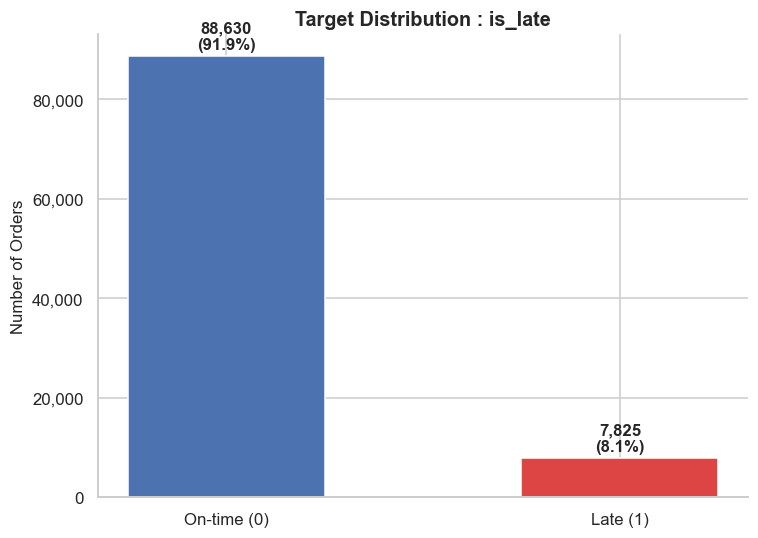

Class imbalance ratio : 11.3 : 1  (on-time : late)


In [3]:
fig, ax = plt.subplots(figsize=(7, 5))
counts = df['is_late'].value_counts().sort_index()
bars = ax.bar(['On-time (0)', 'Late (1)'], counts.values,
              color=PALETTE, edgecolor='white', width=0.5)

for bar, val in zip(bars, counts.values):
    pct = val / len(df) * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 800,
            f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom',
            fontweight='bold', fontsize=11)

ax.set_title('Target Distribution : is_late')
ax.set_ylabel('Number of Orders')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
sns.despine()
plt.tight_layout()
plt.show()

ratio = (df['is_late'] == 0).sum() / (df['is_late'] == 1).sum()
print(f'Class imbalance ratio : {ratio:.1f} : 1  (on-time : late)')

**Insight:** The target is heavily imbalanced at roughly 11 : 1.
A naive "always predict on-time" baseline already achieves ~92% accuracy, so the model must
beat that meaningfully. Imbalance-aware techniques (class weights, SMOTE, threshold tuning)
and evaluation metrics beyond accuracy (F1, precision-recall AUC) will be required.

---
## 2 — Key Variable Distributions

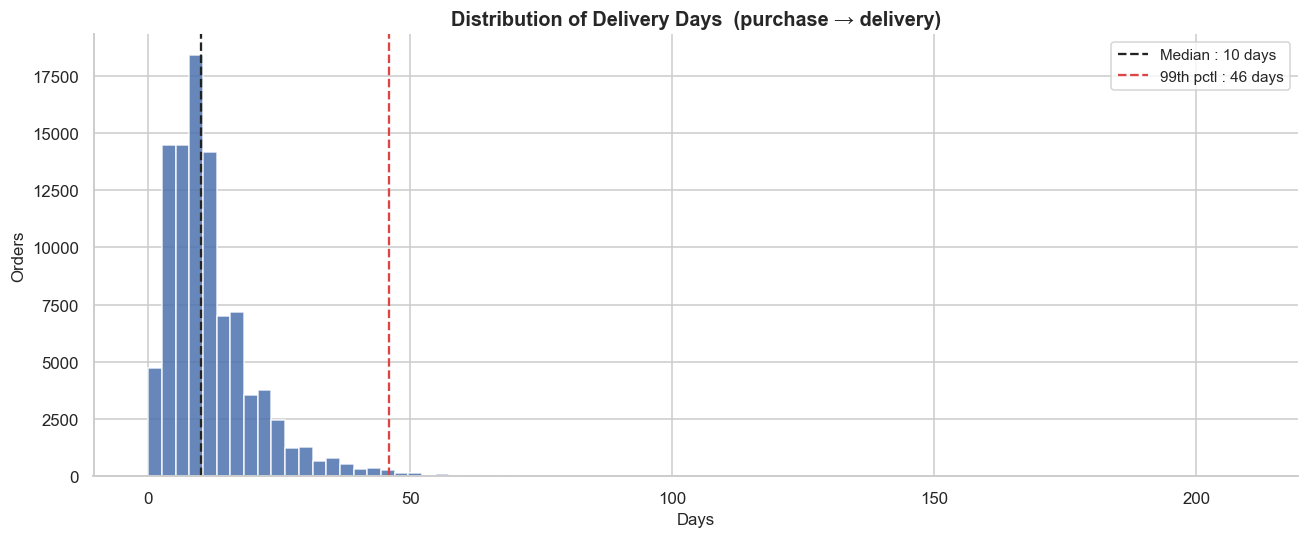

Mean : 12.1 d  |  Median : 10 d  |  Std : 9.6 d  |  Range : 0–209 d


In [4]:
dd = df['delivery_days'].dropna()

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(dd, bins=80, color=ON_TIME_C, edgecolor='white', alpha=0.85)

med = dd.median()
p99 = dd.quantile(0.99)
ax.axvline(med, color='#222', ls='--', lw=1.5, label=f'Median : {med:.0f} days')
ax.axvline(p99, color=LATE_C, ls='--', lw=1.5, label=f'99th pctl : {p99:.0f} days')

ax.set_title('Distribution of Delivery Days  (purchase \u2192 delivery)')
ax.set_xlabel('Days')
ax.set_ylabel('Orders')
ax.legend(fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()

print(f'Mean : {dd.mean():.1f} d  |  Median : {med:.0f} d  |  Std : {dd.std():.1f} d  |  Range : {dd.min():.0f}\u2013{dd.max():.0f} d')

**Insight:** Delivery days are right-skewed with a long tail past 40+ days.
Most orders arrive within 3–4 weeks, but the gap between median and 99th percentile
signals high variance that the model must capture. The extreme tail is overwhelmingly composed
of confirmed late deliveries (96.5%, verified in NB01).

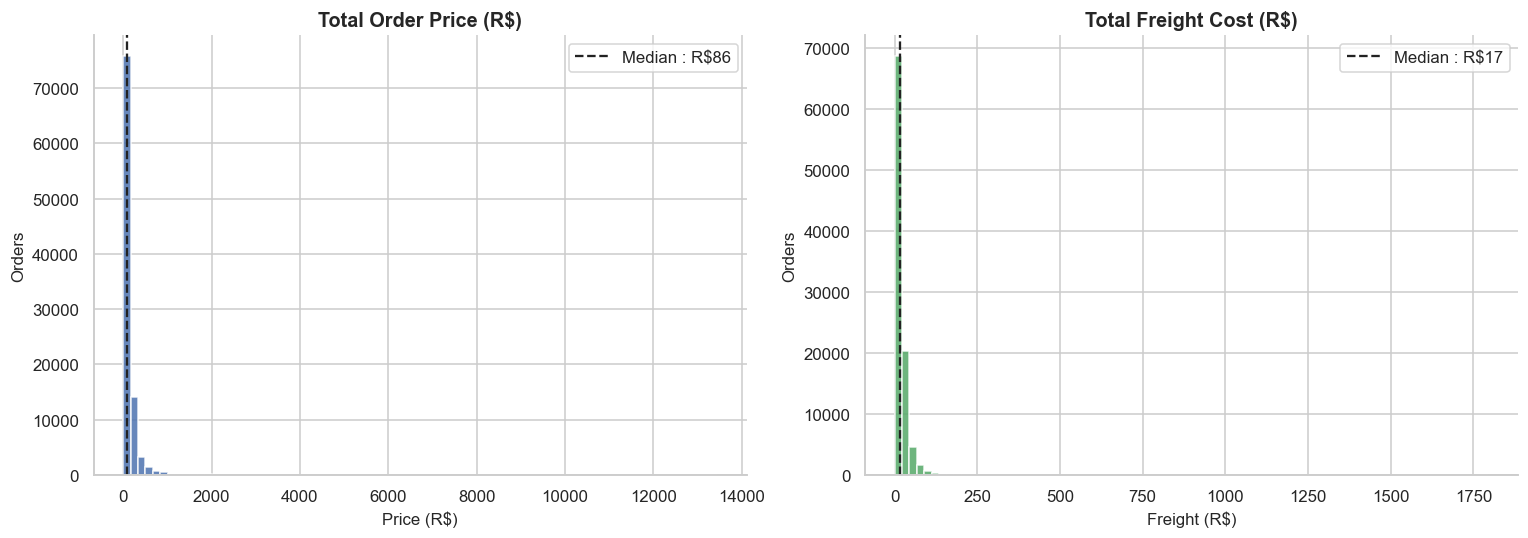

Price   — Median: R$86.50 | Mean: R$137.04 | Max: R$13,440.00
Freight — Median: R$17.17 | Mean: R$22.79 | Max: R$1,794.96


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['total_price'].dropna(), bins=80, color=ON_TIME_C,
             edgecolor='white', alpha=0.85)
med_p = df['total_price'].median()
axes[0].axvline(med_p, color='#222', ls='--', lw=1.5,
                label=f'Median : R${med_p:,.0f}')
axes[0].set_title('Total Order Price (R$)')
axes[0].set_xlabel('Price (R$)')
axes[0].set_ylabel('Orders')
axes[0].legend()

axes[1].hist(df['total_freight'].dropna(), bins=80, color=ACCENT_C,
             edgecolor='white', alpha=0.85)
med_f = df['total_freight'].median()
axes[1].axvline(med_f, color='#222', ls='--', lw=1.5,
                label=f'Median : R${med_f:,.0f}')
axes[1].set_title('Total Freight Cost (R$)')
axes[1].set_xlabel('Freight (R$)')
axes[1].set_ylabel('Orders')
axes[1].legend()

for ax in axes:
    sns.despine(ax=ax)
plt.tight_layout()
plt.show()

print(f'Price   \u2014 Median: R${med_p:,.2f} | Mean: R${df["total_price"].mean():,.2f} | Max: R${df["total_price"].max():,.2f}')
print(f'Freight \u2014 Median: R${med_f:,.2f} | Mean: R${df["total_freight"].mean():,.2f} | Max: R${df["total_freight"].max():,.2f}')

**Insight:** Both price and freight are heavily right-skewed — most orders are
low-to-moderate value with a long tail of high-value orders. Log transformation should
improve model performance for these features.

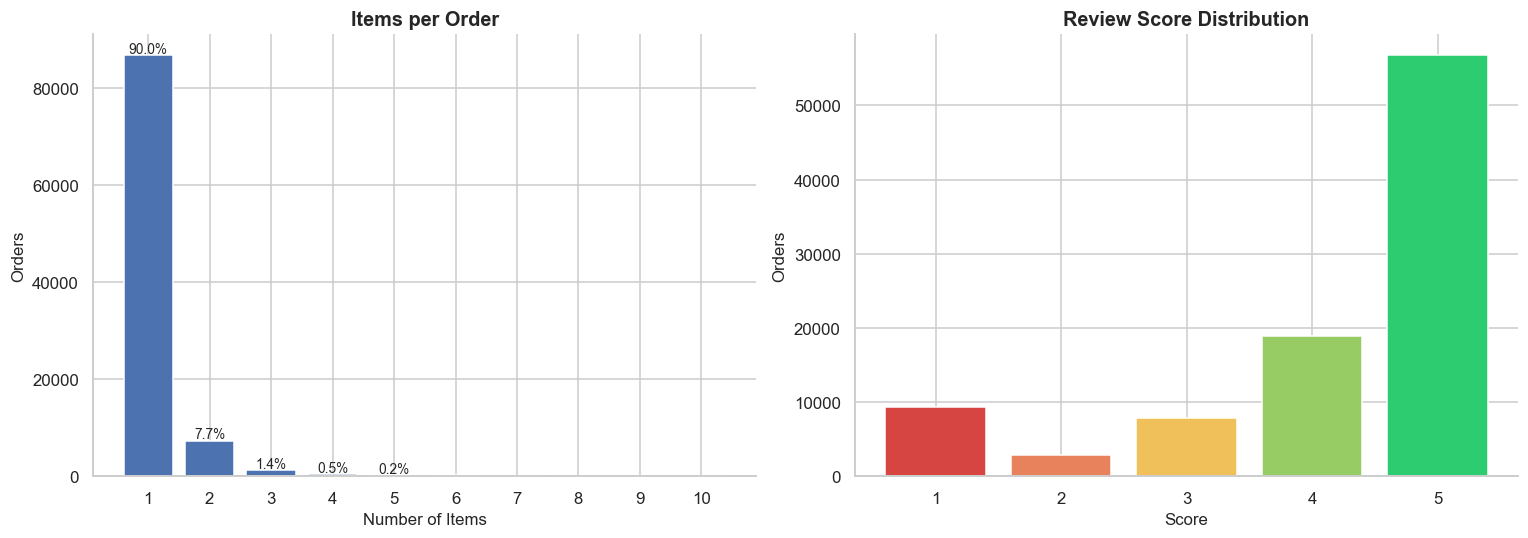

Single-item orders : 90.0%
Review score — Median: 5 | Mean: 4.16


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Items per order
item_cts = df['n_items'].value_counts().sort_index().head(10)
axes[0].bar(item_cts.index.astype(str), item_cts.values,
            color=ON_TIME_C, edgecolor='white')
axes[0].set_title('Items per Order')
axes[0].set_xlabel('Number of Items')
axes[0].set_ylabel('Orders')
for i, (idx, val) in enumerate(item_cts.items()):
    if i < 5:
        axes[0].text(i, val + 500, f'{val/len(df)*100:.1f}%',
                     ha='center', fontsize=9)

# Review score
r_cts = df['review_score'].dropna().astype(int).value_counts().sort_index()
score_colors = ['#D64541', '#E8825C', '#F0C05A', '#97CB64', '#2ECC71']
axes[1].bar(r_cts.index.astype(str), r_cts.values,
            color=score_colors, edgecolor='white')
axes[1].set_title('Review Score Distribution')
axes[1].set_xlabel('Score')
axes[1].set_ylabel('Orders')

for ax in axes:
    sns.despine(ax=ax)
plt.tight_layout()
plt.show()

single_pct = (df['n_items'] == 1).mean() * 100
print(f'Single-item orders : {single_pct:.1f}%')
print(f'Review score \u2014 Median: {df["review_score"].median():.0f} | Mean: {df["review_score"].mean():.2f}')

**Insight:** The vast majority of orders contain a single item — multi-item orders are
uncommon but may behave differently (more sellers, higher weight, more logistic complexity).
Review scores follow a J-shaped distribution: 5-star dominates, followed by 1-star, with
middle scores least common. This polarization is typical of marketplace review systems.

> ⚠️ `review_score` is post-delivery information — EDA-only, excluded from model features.

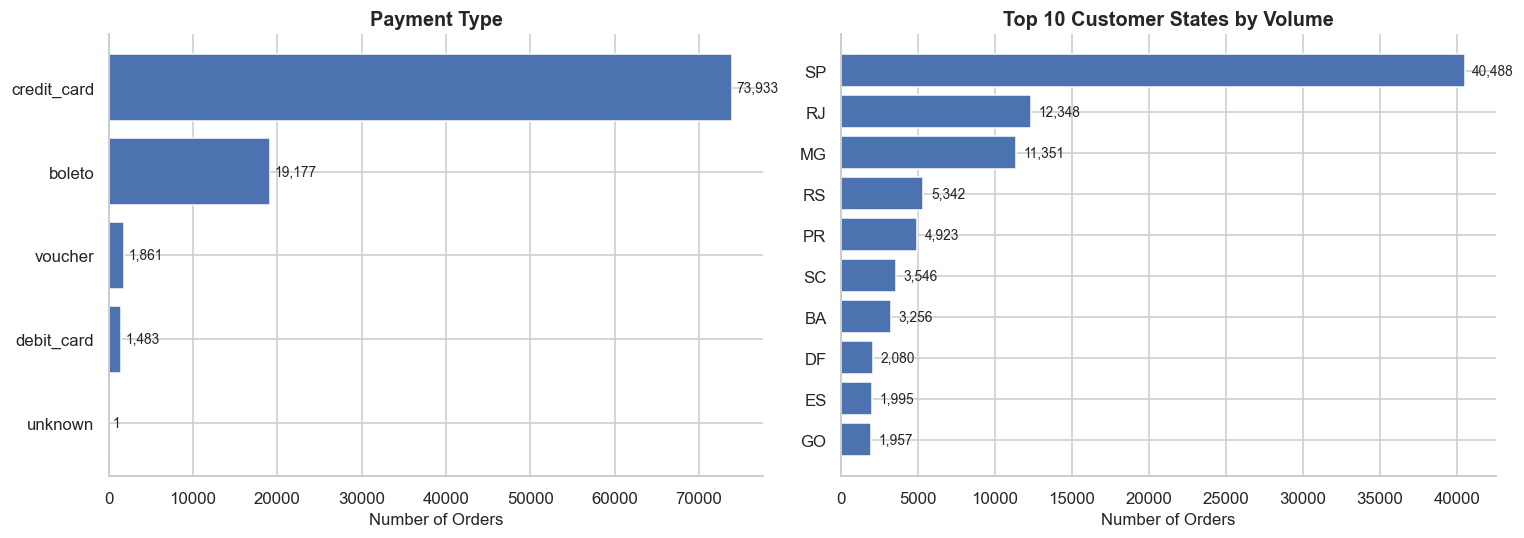

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Payment type
pt_cts = df['payment_type'].value_counts()
axes[0].barh(pt_cts.index[::-1], pt_cts.values[::-1],
             color=ON_TIME_C, edgecolor='white')
axes[0].set_title('Payment Type')
axes[0].set_xlabel('Number of Orders')
for i, val in enumerate(pt_cts.values[::-1]):
    axes[0].text(val + 500, i, f'{val:,}', va='center', fontsize=9)

# Top 10 states
st_cts = df['customer_state'].value_counts().head(10)
axes[1].barh(st_cts.index[::-1], st_cts.values[::-1],
             color=ON_TIME_C, edgecolor='white')
axes[1].set_title('Top 10 Customer States by Volume')
axes[1].set_xlabel('Number of Orders')
for i, val in enumerate(st_cts.values[::-1]):
    axes[1].text(val + 500, i, f'{val:,}', va='center', fontsize=9)

for ax in axes:
    sns.despine(ax=ax)
plt.tight_layout()
plt.show()

**Insight:** Credit card is the dominant payment method by a wide margin.
São Paulo (SP) accounts for the largest share of orders, followed by Rio de Janeiro (RJ)
and Minas Gerais (MG) — reflecting Brazil’s population and economic concentration in the
Southeast.

---
## 3 — Relationships with Target (`is_late`)

How do features behave differently for late vs on-time deliveries?

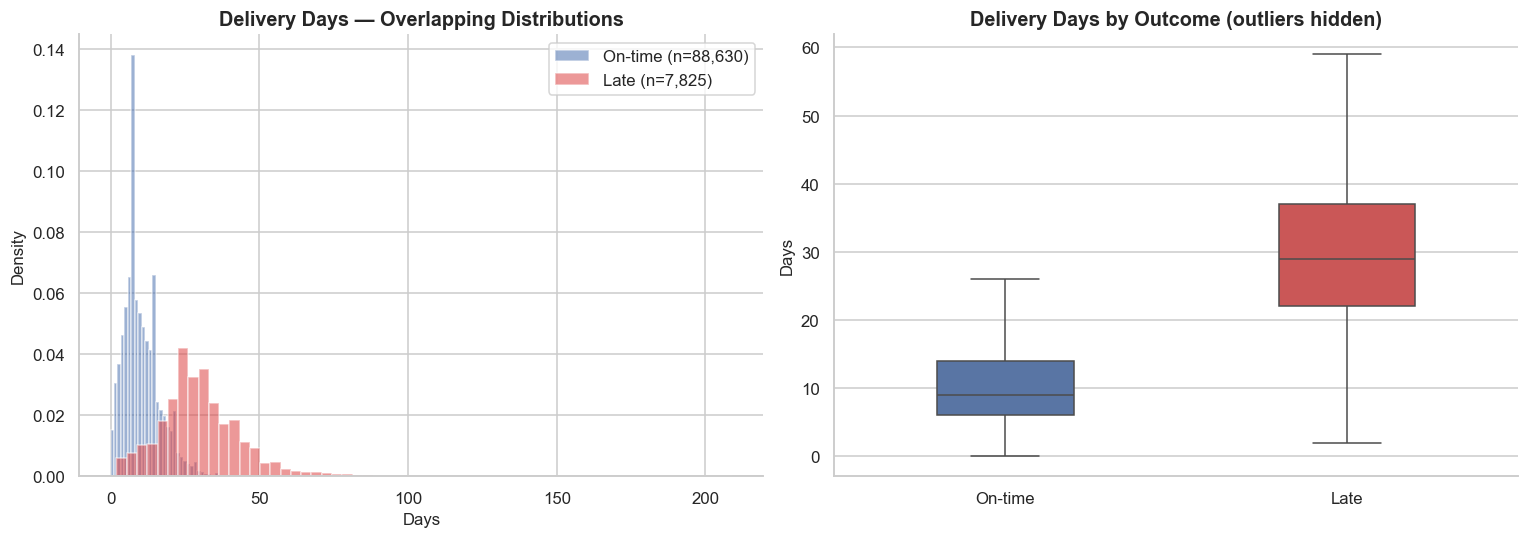

On-time  — Median:     9 d | Mean:  10.4 d | Std:   6.2
Late     — Median:    29 d | Mean:  31.1 d | Std:  17.3


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for val, label, color in [(0, 'On-time', ON_TIME_C), (1, 'Late', LATE_C)]:
    subset = df[df['is_late'] == val]['delivery_days'].dropna()
    axes[0].hist(subset, bins=60, alpha=0.55, density=True,
                 label=f'{label} (n={len(subset):,})', color=color)
axes[0].set_title('Delivery Days \u2014 Overlapping Distributions')
axes[0].set_xlabel('Days')
axes[0].set_ylabel('Density')
axes[0].legend()

sns.boxplot(data=df, x='is_late', y='delivery_days',
            palette=PALETTE, ax=axes[1], showfliers=False, width=0.4)
axes[1].set_xticklabels(['On-time', 'Late'])
axes[1].set_title('Delivery Days by Outcome (outliers hidden)')
axes[1].set_ylabel('Days')
axes[1].set_xlabel('')

for ax in axes:
    sns.despine(ax=ax)
plt.tight_layout()
plt.show()

for label, val in [('On-time', 0), ('Late', 1)]:
    s = df[df['is_late'] == val]['delivery_days']
    print(f'{label:8s} \u2014 Median: {s.median():5.0f} d | Mean: {s.mean():5.1f} d | Std: {s.std():5.1f}')

**Insight:** Late deliveries take substantially longer — the distributions barely overlap.
`delivery_days` is a powerful EDA descriptor of the outcome, but it **cannot be used as a
model feature** because it is computed from the actual delivery date (post-delivery leakage).
The modelling challenge is to predict this outcome using only pre-shipment information.

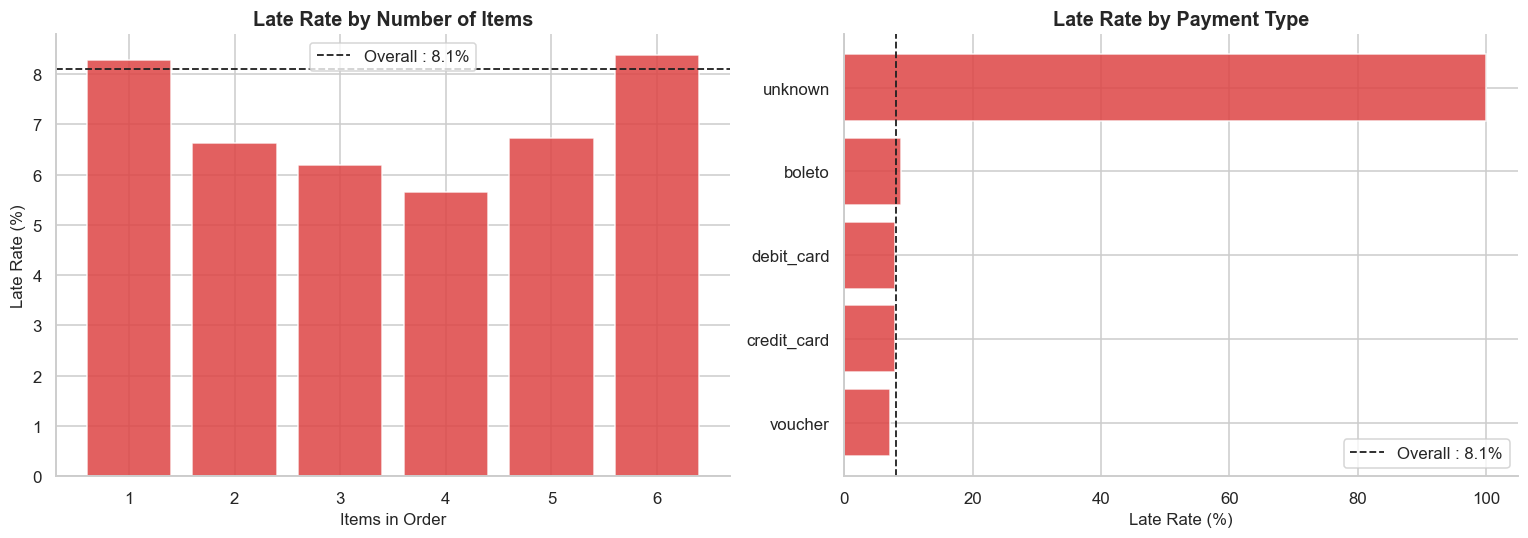

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
overall = df['is_late'].mean() * 100

# By n_items
grp = df.groupby('n_items')['is_late'].agg(['mean', 'count']).reset_index()
grp = grp[grp['count'] >= 50]
axes[0].bar(grp['n_items'].astype(str), grp['mean'] * 100,
            color=LATE_C, edgecolor='white', alpha=0.85)
axes[0].axhline(overall, ls='--', color='#222', lw=1.2,
                label=f'Overall : {overall:.1f}%')
axes[0].set_title('Late Rate by Number of Items')
axes[0].set_xlabel('Items in Order')
axes[0].set_ylabel('Late Rate (%)')
axes[0].legend()

# By payment_type
pt = df.groupby('payment_type')['is_late'].mean().sort_values() * 100
axes[1].barh(pt.index, pt.values, color=LATE_C, edgecolor='white', alpha=0.85)
axes[1].axvline(overall, ls='--', color='#222', lw=1.2,
                label=f'Overall : {overall:.1f}%')
axes[1].set_title('Late Rate by Payment Type')
axes[1].set_xlabel('Late Rate (%)')
axes[1].legend()

for ax in axes:
    sns.despine(ax=ax)
plt.tight_layout()
plt.show()

**Insight:** Multi-item orders show a higher late rate — likely because they involve more
sellers, heavier packages, or more complex logistics coordination. Payment type shows some
variation: boleto (bank slip) orders may differ because boleto requires a separate payment
confirmation step that adds processing time before shipment.

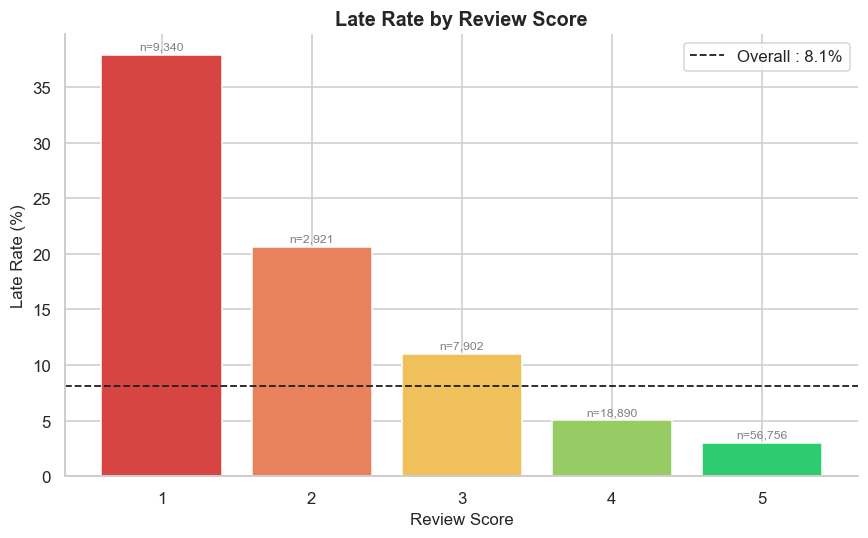

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
rl = (df.dropna(subset=['review_score'])
        .groupby('review_score')['is_late']
        .agg(['mean', 'count']).reset_index())

score_colors = ['#D64541', '#E8825C', '#F0C05A', '#97CB64', '#2ECC71']
bars = ax.bar(rl['review_score'].astype(int).astype(str),
              rl['mean'] * 100, color=score_colors, edgecolor='white')
ax.axhline(df['is_late'].mean() * 100, ls='--', color='#222', lw=1.2,
           label=f'Overall : {df["is_late"].mean()*100:.1f}%')

for bar, (_, row) in zip(bars, rl.iterrows()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'n={row["count"]:,.0f}', ha='center', fontsize=8, color='grey')

ax.set_title('Late Rate by Review Score')
ax.set_xlabel('Review Score')
ax.set_ylabel('Late Rate (%)')
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

**Insight:** Strong inverse relationship — customers who experienced late delivery are far
more likely to leave 1–2 star reviews. This confirms the link between delivery experience and
satisfaction.

> ⚠️ `review_score` is collected *after* delivery — it reflects the outcome, not a
> predictor of it. EDA-only; must be excluded from the model.

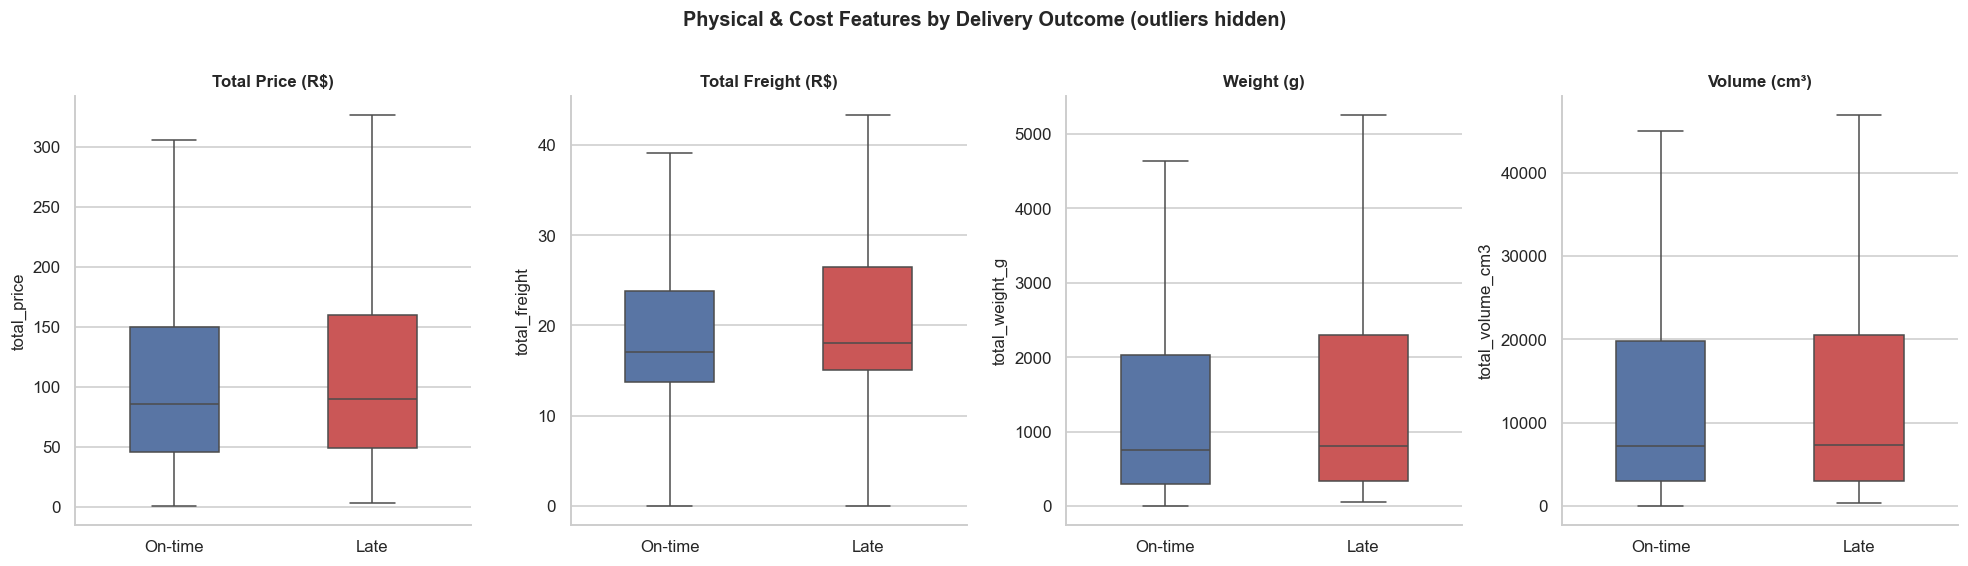

Median comparison (on-time vs late):
  total_price           On-time:       85.5  |  Late:       89.9  |  Δ +5.1%
  total_freight         On-time:       17.1  |  Late:       18.1  |  Δ +5.8%
  total_weight_g        On-time:      750.0  |  Late:      800.0  |  Δ +6.7%
  total_volume_cm3      On-time:    7,245.0  |  Late:    7,296.0  |  Δ +0.7%


In [11]:
features = ['total_price', 'total_freight', 'total_weight_g', 'total_volume_cm3']
labels   = ['Total Price (R$)', 'Total Freight (R$)', 'Weight (g)', 'Volume (cm\u00B3)']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, feat, lbl in zip(axes, features, labels):
    sns.boxplot(data=df, x='is_late', y=feat, palette=PALETTE,
                ax=ax, showfliers=False, width=0.45)
    ax.set_xticklabels(['On-time', 'Late'])
    ax.set_title(lbl, fontsize=11)
    ax.set_xlabel('')
    sns.despine(ax=ax)

plt.suptitle('Physical & Cost Features by Delivery Outcome (outliers hidden)',
             fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print('Median comparison (on-time vs late):')
for feat in features:
    ot = df[df['is_late'] == 0][feat].median()
    lt = df[df['is_late'] == 1][feat].median()
    delta = (lt - ot) / ot * 100 if ot != 0 else 0
    print(f'  {feat:<20s}  On-time: {ot:>10,.1f}  |  Late: {lt:>10,.1f}  |  \u0394 {delta:+.1f}%')

**Insight:** Late orders tend to have higher freight, greater weight, and larger volume.
This makes physical sense — heavier and bulkier items are harder to ship on schedule,
especially to remote destinations. These physical features are promising predictors
because they are known **before shipment** and correlate with the outcome.

### Data Quality Check : Timestamp Issues

NB01 flagged rows with suspicious timestamp ordering (e.g., carrier pickup before payment
approval). We check whether these affect the late rate.

In [12]:
ts_stats = df.groupby('has_timestamp_issue')['is_late'].agg(['mean', 'count'])
ts_stats.index = ['Normal', 'Flagged']
ts_stats.columns = ['late_rate', 'n_orders']
ts_stats['late_rate_pct'] = ts_stats['late_rate'] * 100

print('Late rate by has_timestamp_issue:')
print(ts_stats.to_string())
print(f'\nFlagged orders : {ts_stats.loc["Flagged", "n_orders"]:,.0f}  ({ts_stats.loc["Flagged", "n_orders"]/len(df)*100:.1f}% of data)')
print('\nDecision : Retain flagged rows. The flag itself can serve as a binary feature.')
print('Reason   : Flagged rows are a small fraction; their late rate may differ from normal,')
print('           making the flag informative rather than harmful.')

Late rate by has_timestamp_issue:
         late_rate  n_orders  late_rate_pct
Normal    0.081950     95082       8.195032
Flagged   0.024035      1373       2.403496

Flagged orders : 1,373  (1.4% of data)

Decision : Retain flagged rows. The flag itself can serve as a binary feature.
Reason   : Flagged rows are a small fraction; their late rate may differ from normal,
           making the flag informative rather than harmful.


---
## 4 — Temporal Patterns

Does the late delivery rate vary by when the order was placed?

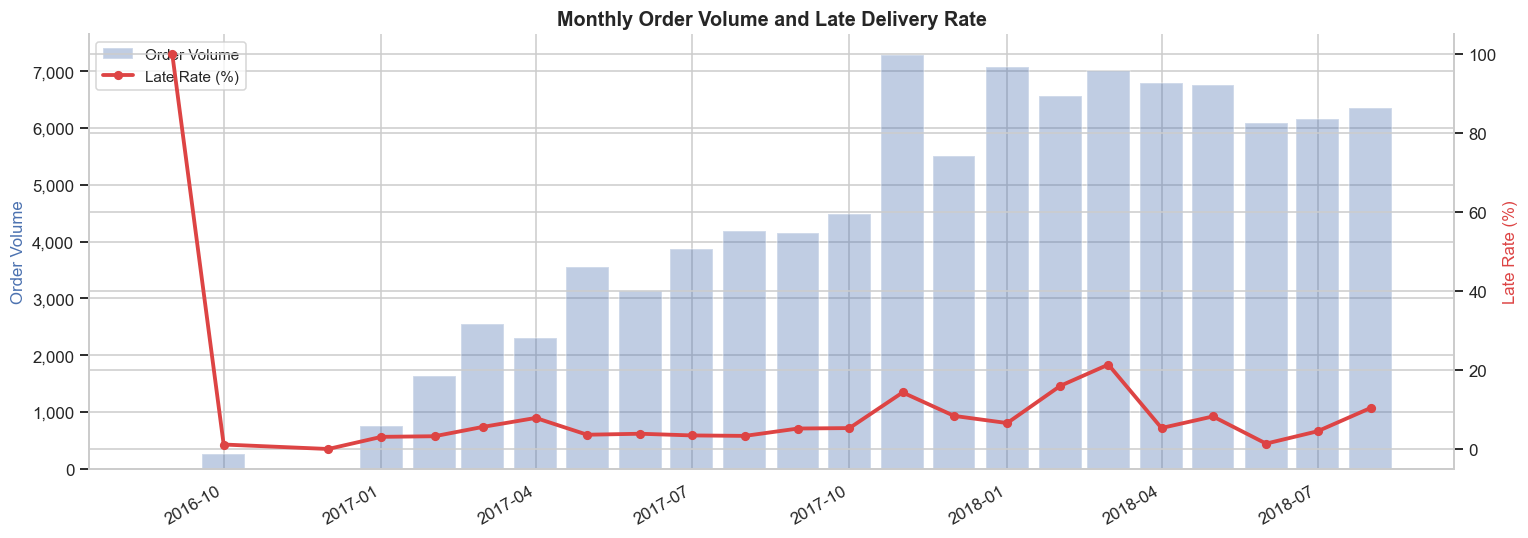

In [13]:
df['purchase_month'] = df['order_purchase_timestamp'].dt.to_period('M')
monthly = df.groupby('purchase_month').agg(
    volume=('order_id', 'count'),
    late_rate=('is_late', 'mean')
).reset_index()
monthly['purchase_month'] = monthly['purchase_month'].dt.to_timestamp()

fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.bar(monthly['purchase_month'], monthly['volume'],
        color=ON_TIME_C, alpha=0.35, width=25, label='Order Volume')
ax1.set_ylabel('Order Volume', color=ON_TIME_C)
ax1.set_xlabel('')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

ax2 = ax1.twinx()
ax2.plot(monthly['purchase_month'], monthly['late_rate'] * 100,
         color=LATE_C, marker='o', lw=2.5, markersize=5, label='Late Rate (%)')
ax2.set_ylabel('Late Rate (%)', color=LATE_C)

ax1.set_title('Monthly Order Volume and Late Delivery Rate')
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='upper left', fontsize=10)
fig.autofmt_xdate()
sns.despine(right=False)
plt.tight_layout()
plt.show()

**Insight:** The late rate is not constant over time — spikes may correspond to seasonal
demand surges (Black Friday, holiday season) when logistics capacity is strained. Purchase
month or quarter could be a useful temporal feature. Note also the early-period ramp-up as
Olist was growing and establishing its logistics network.

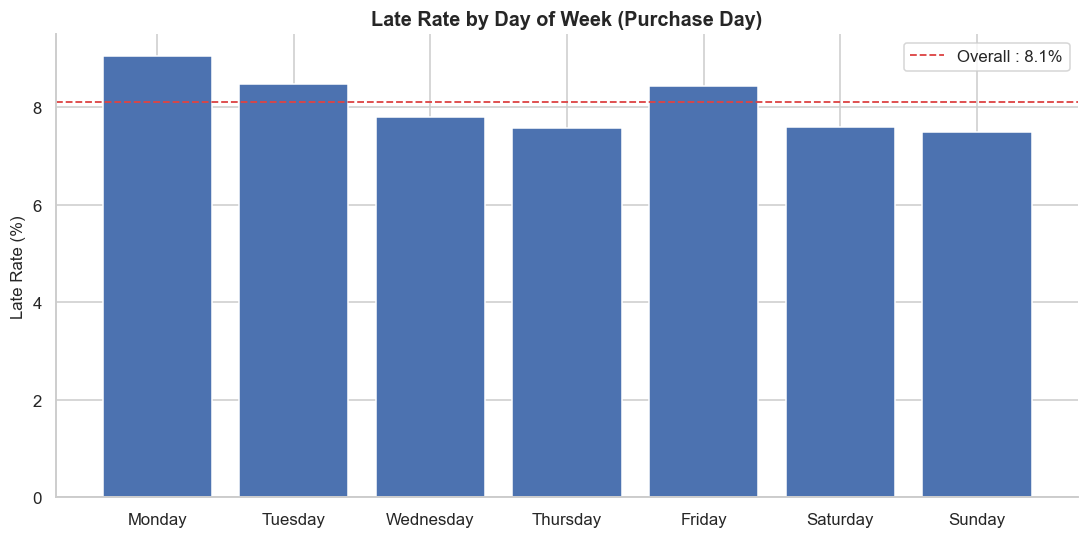

In [14]:
df['purchase_dow'] = df['order_purchase_timestamp'].dt.day_name()
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow = df.groupby('purchase_dow')['is_late'].agg(['mean', 'count']).reindex(dow_order)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(dow.index, dow['mean'] * 100, color=ON_TIME_C, edgecolor='white')
ax.axhline(df['is_late'].mean() * 100, ls='--', color=LATE_C, lw=1.2,
           label=f'Overall : {df["is_late"].mean()*100:.1f}%')
ax.set_title('Late Rate by Day of Week (Purchase Day)')
ax.set_ylabel('Late Rate (%)')
ax.set_xlabel('')
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

**Insight:** Day-of-week variation is modest but visible. Orders placed towards the weekend
may face slight delays because logistics operations are reduced on Saturdays and Sundays.
Day-of-week is a cheap feature to engineer and worth including.

### Time of Day Analysis

Does the hour of purchase affect delivery timeliness?

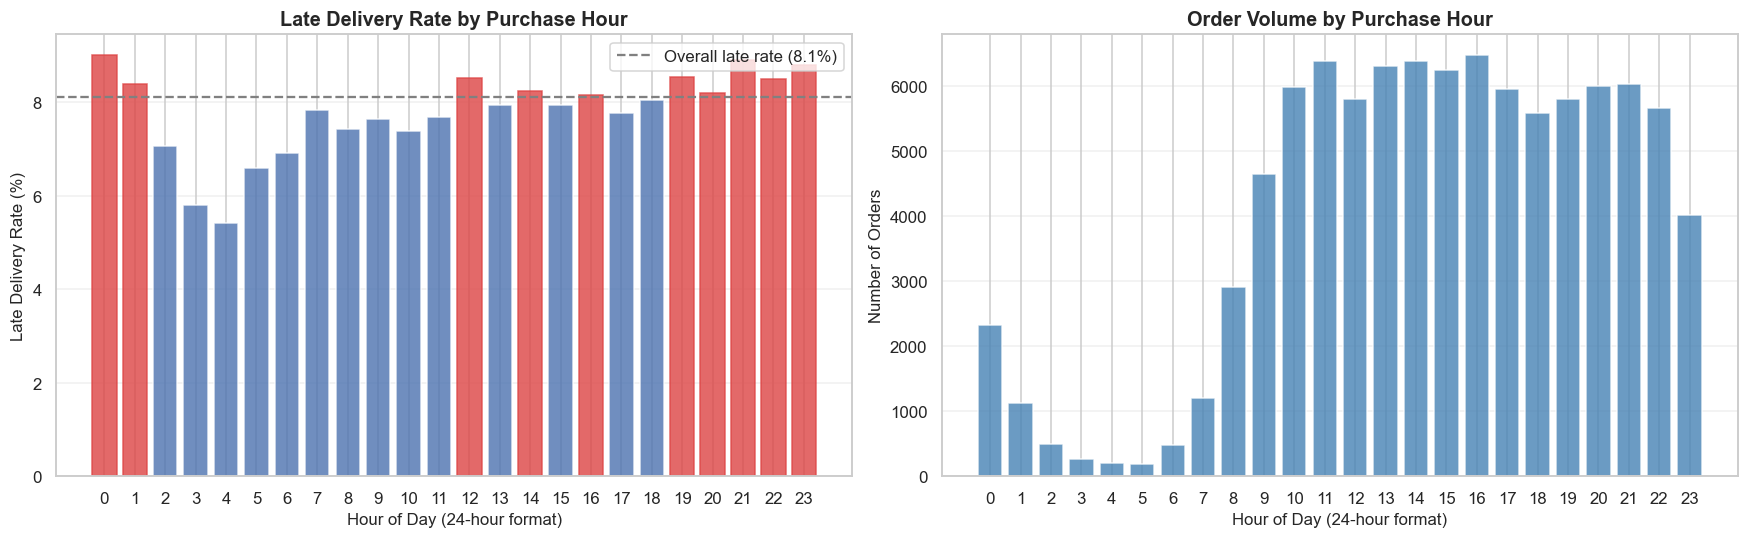


--- Peak hours analysis ---
Highest late rate: 0:00 (9.0%)
Lowest late rate: 4:00 (5.4%)
Busiest hour: 16:00 (6,474 orders)
Quietest hour: 5:00 (182 orders)


In [16]:
df['purchase_hour'] = df['order_purchase_timestamp'].dt.hour

hourly = df.groupby('purchase_hour').agg(
    n_orders=('order_id', 'count'),
    late_rate=('is_late', 'mean')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax1 = axes[0]
bars = ax1.bar(hourly['purchase_hour'], hourly['late_rate'] * 100, 
               color=ON_TIME_C, edgecolor='white', alpha=0.8)
ax1.axhline(df['is_late'].mean() * 100, ls='--', color='gray', lw=1.5, 
            label=f"Overall late rate ({df['is_late'].mean()*100:.1f}%)")

for i, (idx, row) in enumerate(hourly.iterrows()):
    if row['late_rate'] > df['is_late'].mean():
        bars[i].set_color(LATE_C)

ax1.set_xlabel('Hour of Day (24-hour format)', fontsize=11)
ax1.set_ylabel('Late Delivery Rate (%)', fontsize=11)
ax1.set_title('Late Delivery Rate by Purchase Hour', fontsize=13, fontweight='bold')
ax1.set_xticks(range(0, 24))
ax1.legend(loc='upper right')
ax1.grid(axis='y', alpha=0.3)

ax2 = axes[1]
ax2.bar(hourly['purchase_hour'], hourly['n_orders'], 
        color='steelblue', edgecolor='white', alpha=0.8)
ax2.set_xlabel('Hour of Day (24-hour format)', fontsize=11)
ax2.set_ylabel('Number of Orders', fontsize=11)
ax2.set_title('Order Volume by Purchase Hour', fontsize=13, fontweight='bold')
ax2.set_xticks(range(0, 24))
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print('\n--- Peak hours analysis ---')
print(f"Highest late rate: {hourly.loc[hourly['late_rate'].idxmax(), 'purchase_hour']:.0f}:00 ({hourly['late_rate'].max()*100:.1f}%)")
print(f"Lowest late rate: {hourly.loc[hourly['late_rate'].idxmin(), 'purchase_hour']:.0f}:00 ({hourly['late_rate'].min()*100:.1f}%)")
print(f"Busiest hour: {hourly.loc[hourly['n_orders'].idxmax(), 'purchase_hour']:.0f}:00 ({hourly['n_orders'].max():,.0f} orders)")
print(f"Quietest hour: {hourly.loc[hourly['n_orders'].idxmin(), 'purchase_hour']:.0f}:00 ({hourly['n_orders'].min():,.0f} orders)")

**Insight:** Purchase hour reveals a **distinct temporal pattern** in late delivery rates:

- **Late night / early morning (midnight–6 AM)** show the **highest late rates** (peak at 9.0% at midnight), likely because orders placed during off-peak hours enter the logistics queue when warehouses and carriers have reduced staff, causing processing delays before the next business day.

- **Mid-morning to early afternoon (4 AM–noon)** achieve the **lowest late rates** (bottom at 5.4% at 4 AM), suggesting these orders benefit from immediate same-day processing when logistics operations are at full capacity.

- **Afternoon rush (1 PM–6 PM)** maintains moderate late rates around 8%, despite being the **busiest period** (peak at 6,474 orders at 4 PM). The system handles high daytime volume reasonably well.

- **Evening hours (7 PM–midnight)** see a **gradual increase in late rates** back to 8–9%, as orders placed after business hours may miss same-day carrier pickups and wait until the next morning.

**Order volume** follows expected e-commerce behavior: minimal activity during sleeping hours (2–7 AM), steady growth through the workday, and peak browsing in the late afternoon/evening when customers shop after work.

**Feature engineering implication:** `purchase_hour` (or binned categories like `early_morning`, `business_hours`, `evening`, `night`) is a valuable temporal feature. Consider interaction terms with `purchase_dow` to capture patterns like "Friday evening" vs "Monday morning" orders.

---
## 5 — Geographic Patterns

Does the customer’s location affect the chance of late delivery?

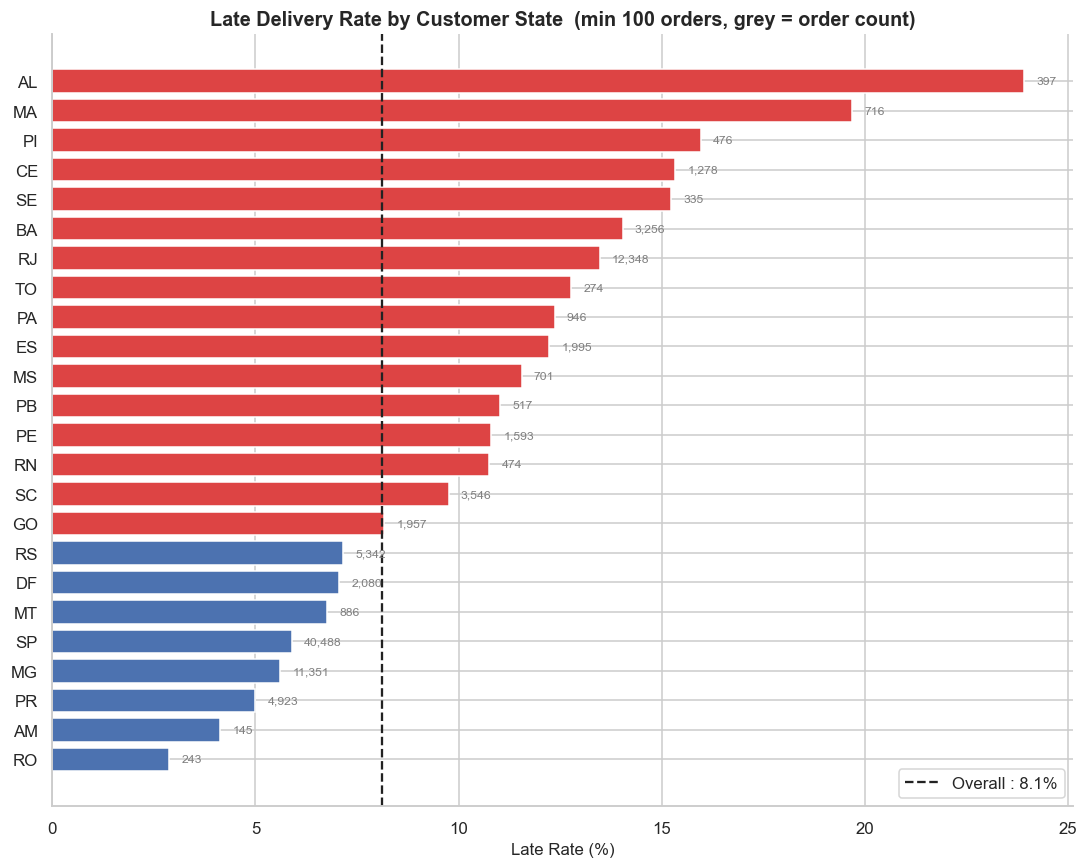

Highest late rates :
  AL : 23.9%  (397 orders)
  MA : 19.7%  (716 orders)
  PI : 16.0%  (476 orders)
Lowest late rates :
  RO : 2.9%  (243 orders)
  AM : 4.1%  (145 orders)
  PR : 5.0%  (4,923 orders)


In [15]:
state_stats = df.groupby('customer_state').agg(
    n_orders=('order_id', 'count'),
    late_rate=('is_late', 'mean')
).reset_index()
state_stats = state_stats[state_stats['n_orders'] >= 100].sort_values('late_rate')

fig, ax = plt.subplots(figsize=(10, 8))
colors = [LATE_C if r > df['is_late'].mean() else ON_TIME_C
          for r in state_stats['late_rate']]
bars = ax.barh(state_stats['customer_state'],
               state_stats['late_rate'] * 100,
               color=colors, edgecolor='white')
ax.axvline(df['is_late'].mean() * 100, ls='--', color='#222', lw=1.5,
           label=f'Overall : {df["is_late"].mean()*100:.1f}%')

for bar, (_, row) in zip(bars, state_stats.iterrows()):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{row["n_orders"]:,}', va='center', fontsize=8, color='grey')

ax.set_title('Late Delivery Rate by Customer State  (min 100 orders, grey = order count)')
ax.set_xlabel('Late Rate (%)')
ax.legend(loc='lower right')
sns.despine()
plt.tight_layout()
plt.show()

top3 = state_stats.nlargest(3, 'late_rate')
bot3 = state_stats.nsmallest(3, 'late_rate')
print('Highest late rates :')
for _, r in top3.iterrows():
    print(f'  {r["customer_state"]} : {r["late_rate"]*100:.1f}%  ({r["n_orders"]:,} orders)')
print('Lowest late rates :')
for _, r in bot3.iterrows():
    print(f'  {r["customer_state"]} : {r["late_rate"]*100:.1f}%  ({r["n_orders"]:,} orders)')

**Insight:** Geography is a strong signal. States in Brazil’s North and Northeast tend to
have significantly higher late rates, while Southeast states (where most Olist sellers are
concentrated) enjoy lower rates. This reflects the physical distance between seller hubs
(mostly SP) and remote customer locations.

**Feature engineering implication:** seller-to-customer distance (computed in NB04 after
selecting a representative seller) should be one of the strongest predictive features.

---
## 6 — Product Category Analysis

Using the item-level dataset to see which product categories are most affected by delays.

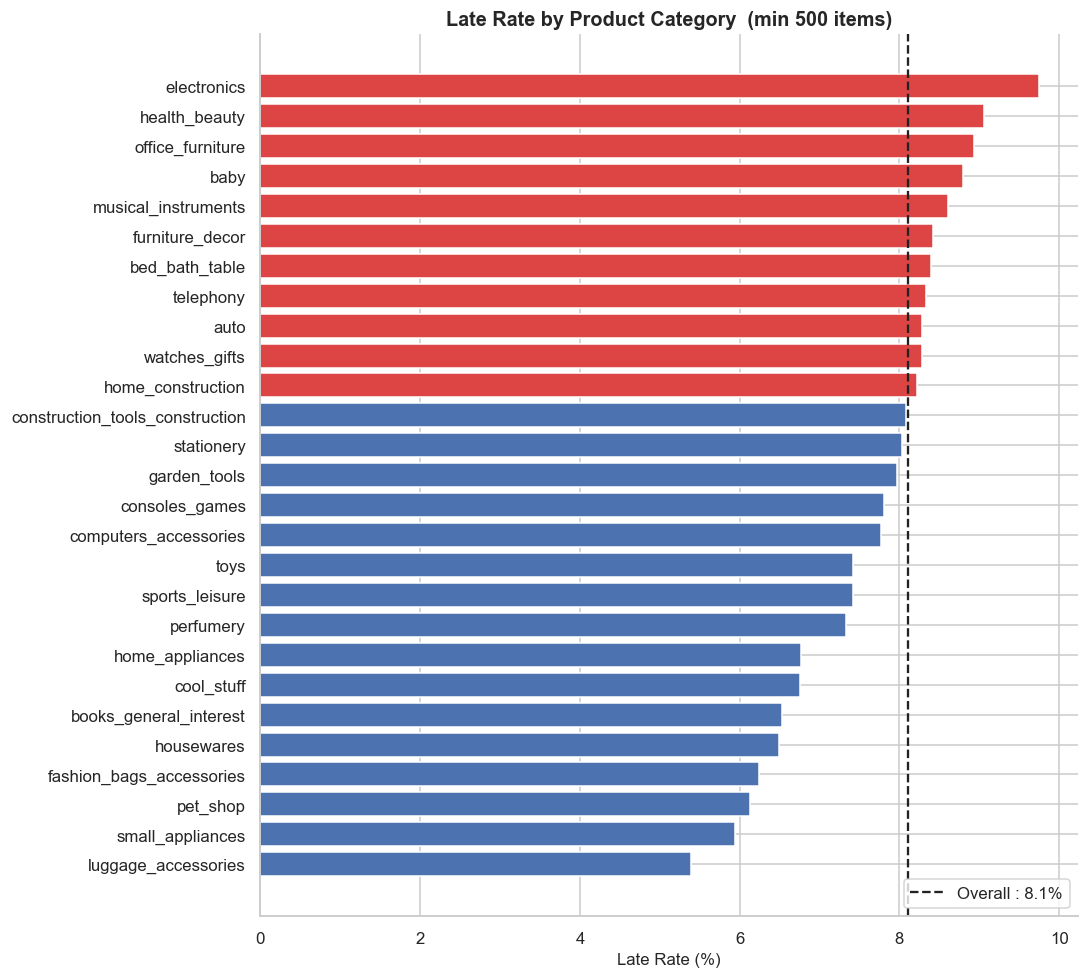

In [34]:
items_with_target = items.merge(
    df[['order_id', 'is_late']], on='order_id', how='inner'
)

cat_stats = (
    items_with_target
    .groupby('product_category_name_english')
    .agg(n_items=('order_id', 'count'), late_rate=('is_late', 'mean'))
    .reset_index()
)
cat_stats = cat_stats[cat_stats['n_items'] >= 500].sort_values('late_rate')

fig, ax = plt.subplots(figsize=(10, 9))
colors = [LATE_C if r > df['is_late'].mean() else ON_TIME_C
          for r in cat_stats['late_rate']]
ax.barh(cat_stats['product_category_name_english'],
        cat_stats['late_rate'] * 100, color=colors, edgecolor='white')
ax.axvline(df['is_late'].mean() * 100, ls='--', color='#222', lw=1.5,
           label=f'Overall : {df["is_late"].mean()*100:.1f}%')
ax.set_title('Late Rate by Product Category  (min 500 items)')
ax.set_xlabel('Late Rate (%)')
ax.legend(loc='lower right')
sns.despine()
plt.tight_layout()
plt.show()

**Insight:** Product categories show meaningful variation in late delivery rates.
But which physical characteristics drive this? The table below profiles each category.

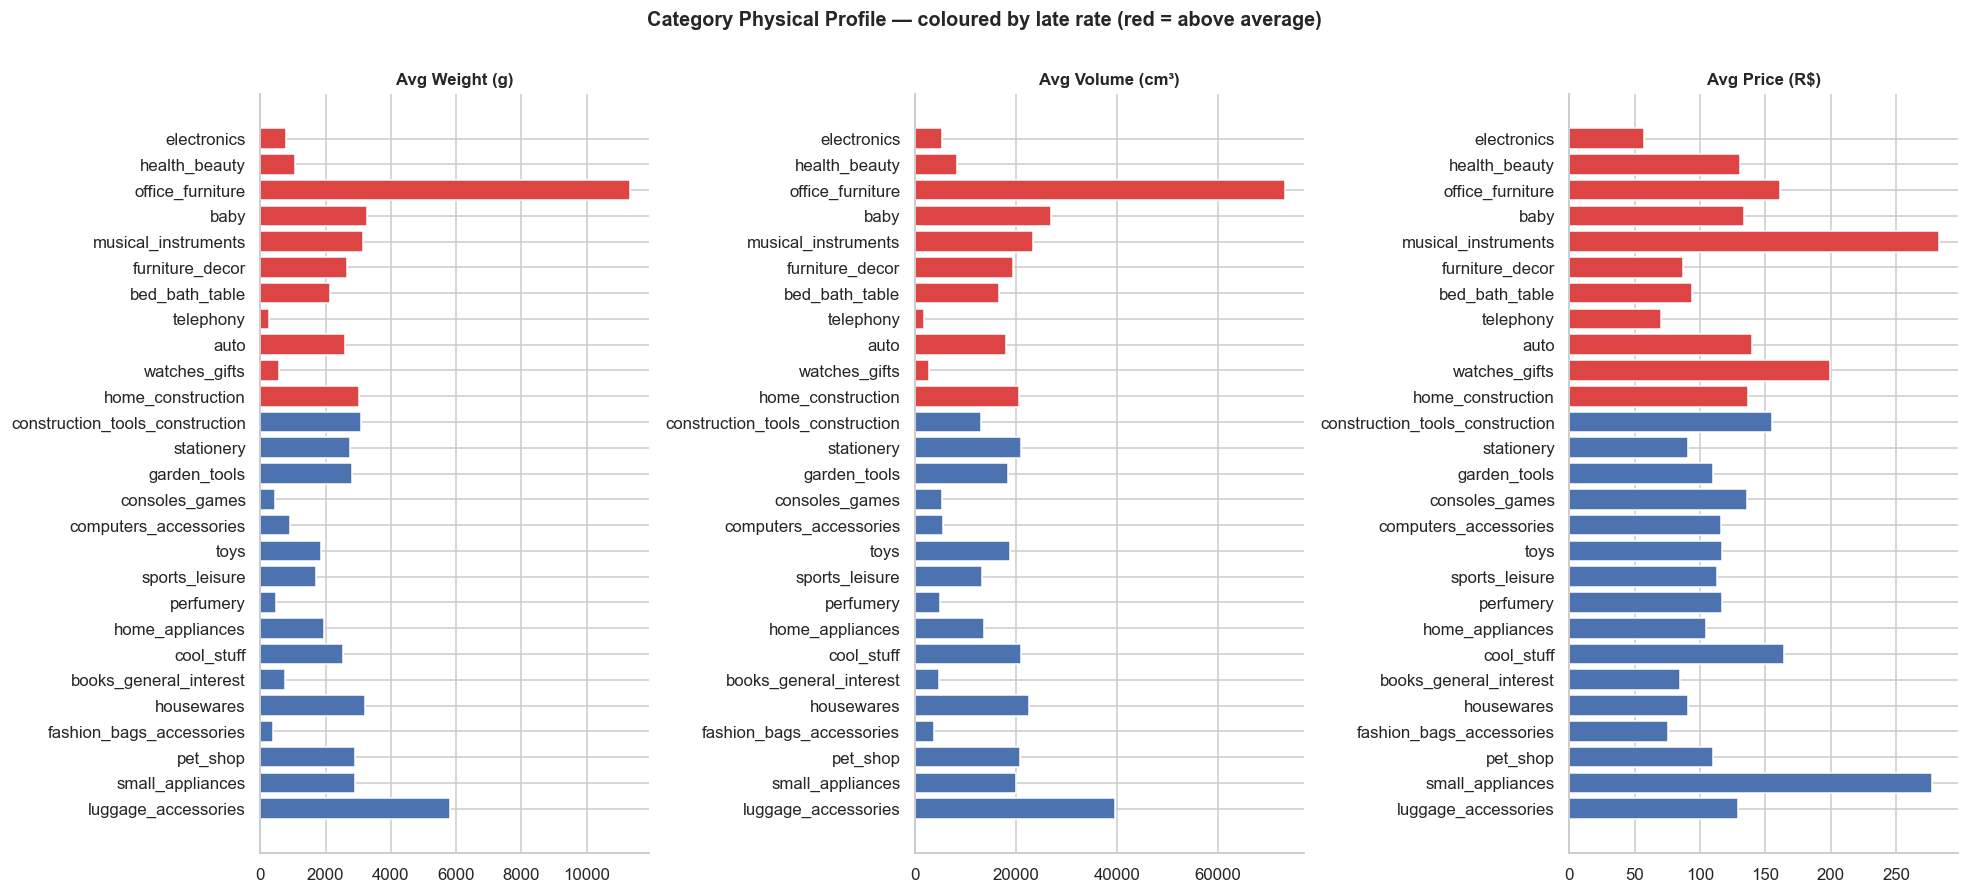

Top 5 categories by late rate with physical profile:
product_category_name_english  n_items  late_rate  avg_weight  avg_volume  avg_price
                  electronics     2729       0.10      771.08     5460.37      56.81
                health_beauty     9465       0.09     1047.38     8276.45     130.28
             office_furniture     1668       0.09    11340.06    73352.96     160.76
                         baby     2981       0.09     3261.33    26961.09     133.68
          musical_instruments      651       0.09     3134.54    23483.54     283.13


In [35]:
cat_profile = (
    items_with_target
    .groupby('product_category_name_english')
    .agg(
        n_items    = ('order_id', 'count'),
        late_rate  = ('is_late', 'mean'),
        avg_weight = ('product_weight_g', 'mean'),
        avg_volume = ('product_volume_cm3', 'mean'),
        avg_price  = ('price', 'mean'),
    )
    .reset_index()
)
cat_profile = cat_profile[cat_profile['n_items'] >= 500].sort_values('late_rate', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 8))
y = cat_profile['product_category_name_english']
colors = [LATE_C if r > df['is_late'].mean() else ON_TIME_C for r in cat_profile['late_rate']]

for ax, col, title, fmt in zip(
    axes,
    ['avg_weight', 'avg_volume', 'avg_price'],
    ['Avg Weight (g)', 'Avg Volume (cm³)', 'Avg Price (R$)'],
    ['{:,.0f}', '{:,.0f}', 'R${:,.0f}']
):
    ax.barh(y, cat_profile[col], color=colors, edgecolor='white')
    ax.set_title(title, fontsize=11)
    ax.invert_yaxis()
    sns.despine(ax=ax)

plt.suptitle('Category Physical Profile — coloured by late rate (red = above average)',
             fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print('Top 5 categories by late rate with physical profile:')
print(cat_profile.head().to_string(index=False, float_format='{:.2f}'.format))

**Insight:** The pattern is clear — categories with the highest late rates (red bars) also
tend to have the heaviest weights and largest volumes. Furniture, home appliances, and similar
bulky categories cluster at the top of all three dimensions. This confirms that **product
category is not just a label — it encodes physical shipping difficulty** that directly maps
to late delivery risk.

For modelling: weight and volume already capture much of this signal numerically, but
category itself may add value for categories where the physical stats alone don't tell the
full story (e.g., fragile items with special handling needs).

---
## 6b — Seller Analysis

Does lateness have to do with the seller? Some sellers may consistently ship late due to
operational capacity, location, or product mix. We use `items_enriched` (item-level) to
profile sellers since the order-level dataset only has seller counts, not identities.

Total unique sellers : 2,970
Sellers with >= 10 orders : 1,237
Sellers with >= 50 orders : 425


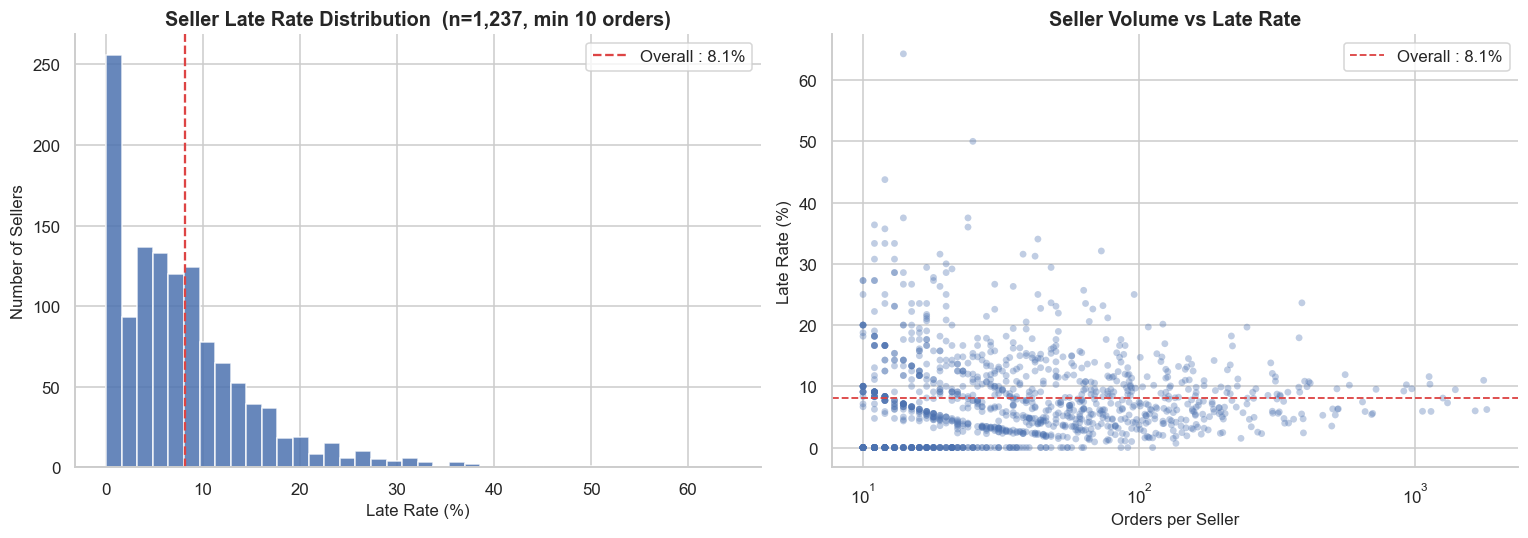


Sellers with 0% late rate   : 19.2%
Sellers with >20% late rate : 5.7%


In [36]:
seller_stats = (
    items_with_target
    .groupby('seller_id')
    .agg(
        n_orders   = ('order_id', 'nunique'),
        late_rate  = ('is_late', 'mean'),
        seller_state = ('seller_state', 'first'),
    )
    .reset_index()
)

print(f'Total unique sellers : {len(seller_stats):,}')
print(f'Sellers with >= 10 orders : {(seller_stats["n_orders"] >= 10).sum():,}')
print(f'Sellers with >= 50 orders : {(seller_stats["n_orders"] >= 50).sum():,}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Late rate distribution across sellers (min 10 orders for stability)
reliable = seller_stats[seller_stats['n_orders'] >= 10]
axes[0].hist(reliable['late_rate'] * 100, bins=40, color=ON_TIME_C,
             edgecolor='white', alpha=0.85)
axes[0].axvline(df['is_late'].mean() * 100, ls='--', color=LATE_C, lw=1.5,
                label=f'Overall : {df["is_late"].mean()*100:.1f}%')
axes[0].set_title(f'Seller Late Rate Distribution  (n={len(reliable):,}, min 10 orders)')
axes[0].set_xlabel('Late Rate (%)')
axes[0].set_ylabel('Number of Sellers')
axes[0].legend()

# Scatter: seller volume vs late rate
axes[1].scatter(reliable['n_orders'], reliable['late_rate'] * 100,
                alpha=0.35, s=20, color=ON_TIME_C, edgecolors='none')
axes[1].axhline(df['is_late'].mean() * 100, ls='--', color=LATE_C, lw=1.2,
                label=f'Overall : {df["is_late"].mean()*100:.1f}%')
axes[1].set_title('Seller Volume vs Late Rate')
axes[1].set_xlabel('Orders per Seller')
axes[1].set_ylabel('Late Rate (%)')
axes[1].set_xscale('log')
axes[1].legend()

for ax in axes:
    sns.despine(ax=ax)
plt.tight_layout()
plt.show()

zero_late = (reliable['late_rate'] == 0).mean() * 100
high_late = (reliable['late_rate'] > 0.20).mean() * 100
print(f'\nSellers with 0% late rate   : {zero_late:.1f}%')
print(f'Sellers with >20% late rate : {high_late:.1f}%')

**Insight:** Seller late rates vary enormously — some sellers never deliver late while others
have rates well above 20%. The scatter plot shows that **high-volume sellers tend to converge
towards the overall average** (regression to the mean), while low-volume sellers show extreme
variance in both directions. This suggests seller identity (or seller-level features) carries
real predictive signal beyond just geography.

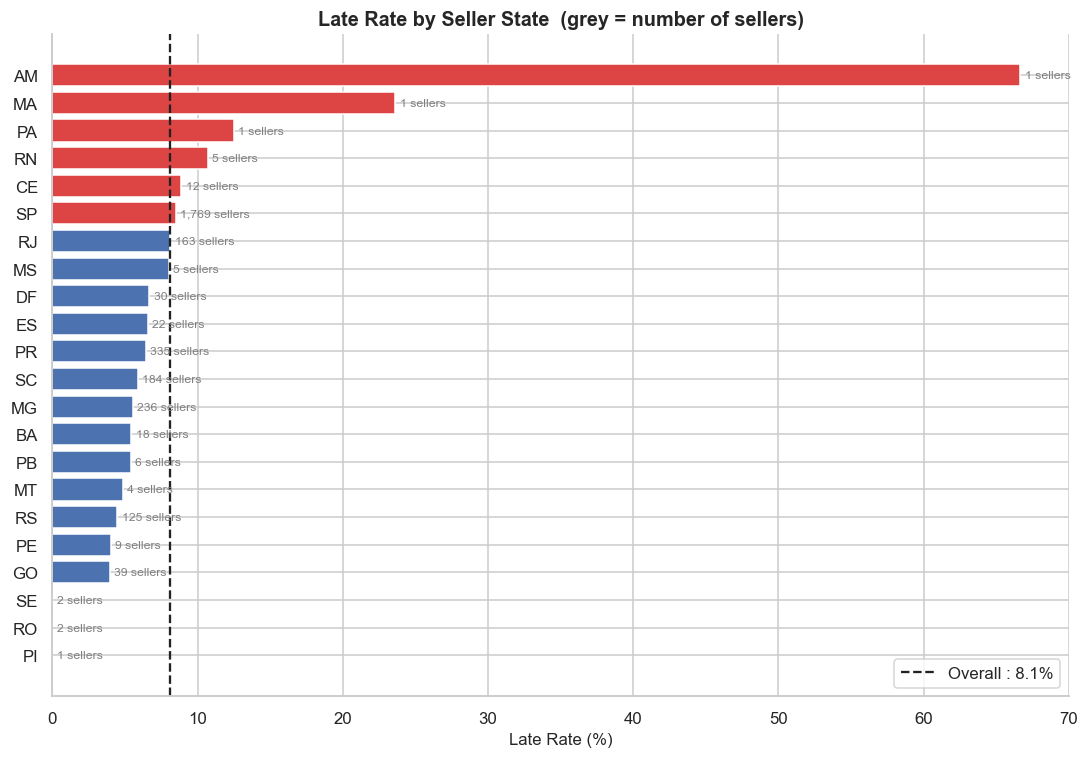

SP concentration:
  SP sellers handle 78,585 items (71.3% of all items)
  SP late rate: 8.5%


In [37]:
seller_state_stats = (
    items_with_target
    .groupby('seller_state')
    .agg(n_items=('order_id', 'count'), late_rate=('is_late', 'mean'),
         n_sellers=('seller_id', 'nunique'))
    .reset_index()
    .sort_values('late_rate')
)

fig, ax = plt.subplots(figsize=(10, 7))
colors = [LATE_C if r > df['is_late'].mean() else ON_TIME_C
          for r in seller_state_stats['late_rate']]
ax.barh(seller_state_stats['seller_state'],
        seller_state_stats['late_rate'] * 100,
        color=colors, edgecolor='white')
ax.axvline(df['is_late'].mean() * 100, ls='--', color='#222', lw=1.5,
           label=f'Overall : {df["is_late"].mean()*100:.1f}%')

for bar, (_, row) in zip(ax.patches, seller_state_stats.iterrows()):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{row["n_sellers"]:,} sellers', va='center', fontsize=8, color='grey')

ax.set_title('Late Rate by Seller State  (grey = number of sellers)')
ax.set_xlabel('Late Rate (%)')
ax.legend(loc='lower right')
sns.despine()
plt.tight_layout()
plt.show()

print('SP concentration:')
sp_items = seller_state_stats[seller_state_stats['seller_state'] == 'SP']['n_items'].values[0]
print(f'  SP sellers handle {sp_items:,} items ({sp_items/len(items_with_target)*100:.1f}% of all items)')
print(f'  SP late rate: {seller_state_stats[seller_state_stats["seller_state"]=="SP"]["late_rate"].values[0]*100:.1f}%')

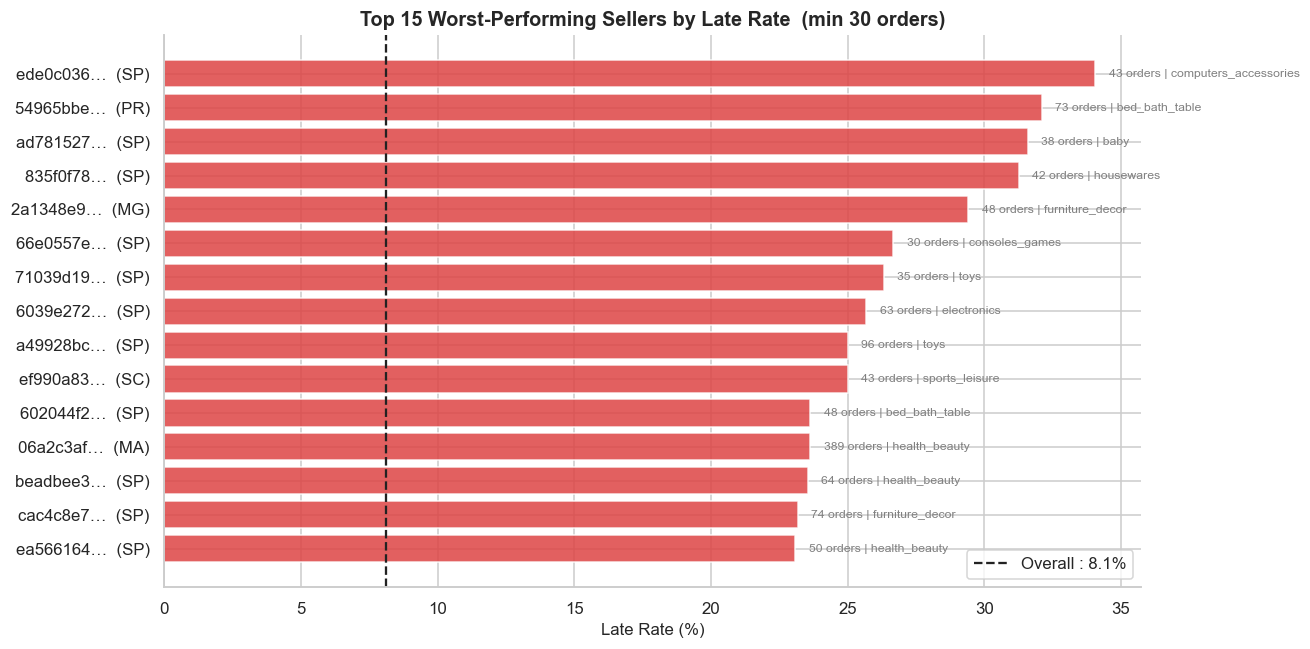

In [38]:
top_sellers = (
    items_with_target
    .groupby('seller_id')
    .agg(
        n_orders   = ('order_id', 'nunique'),
        late_rate  = ('is_late', 'mean'),
        n_late     = ('is_late', 'sum'),
        seller_state = ('seller_state', 'first'),
        top_category = ('product_category_name_english',
                        lambda x: x.mode()[0] if not x.mode().empty else 'unknown'),
    )
    .reset_index()
)
top_late = top_sellers[top_sellers['n_orders'] >= 30].nlargest(15, 'late_rate')

fig, ax = plt.subplots(figsize=(12, 6))
labels = [f'{sid[:8]}…  ({st})' for sid, st in
          zip(top_late['seller_id'], top_late['seller_state'])]
bars = ax.barh(labels[::-1], top_late['late_rate'].values[::-1] * 100,
               color=LATE_C, edgecolor='white', alpha=0.85)
ax.axvline(df['is_late'].mean() * 100, ls='--', color='#222', lw=1.5,
           label=f'Overall : {df["is_late"].mean()*100:.1f}%')

for bar, (_, row) in zip(bars, top_late.iloc[::-1].iterrows()):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{row["n_orders"]} orders | {row["top_category"]}',
            va='center', fontsize=8, color='grey')

ax.set_title('Top 15 Worst-Performing Sellers by Late Rate  (min 30 orders)')
ax.set_xlabel('Late Rate (%)')
ax.legend(loc='lower right')
sns.despine()
plt.tight_layout()
plt.show()

**Insight:**

- **Seller state matters** — sellers in states farther from customer hubs (Southeast) tend to
  have higher late rates, mirroring the customer-side geographic pattern. The combination of
  seller location + customer location (i.e., shipping distance) is likely the strongest signal.
- **Worst sellers are identifiable** — the top 15 worst-performing sellers (30+ orders) have
  late rates far above the 8% average. Their annotations show the product categories they
  primarily sell, connecting seller performance back to category type.
- **Seller-level features for NB04:** seller historical late rate, seller state, seller volume,
  and seller-to-customer distance are all worth engineering. Since we deferred seller geo
  coordinates to NB04, the distance feature will be built there.

---
## 7 — Correlation Analysis

Examining linear relationships between numeric features and their association with the target.

> `delivery_days` and `review_score` are excluded here because they are post-delivery
> (leakage) features. This view focuses on features available **before shipment**.

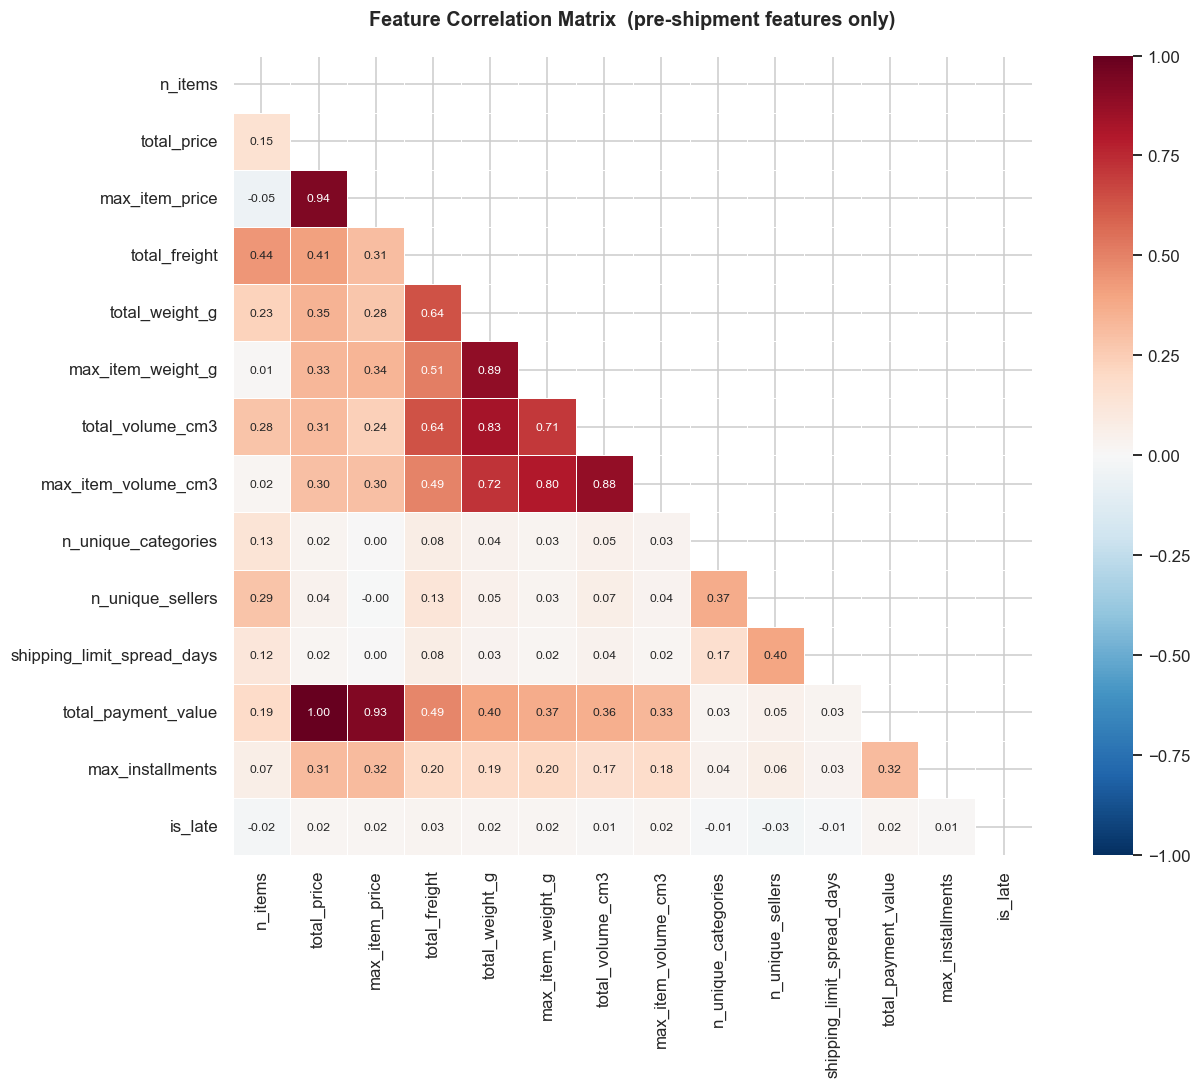

In [39]:
numeric_cols = [
    'n_items', 'total_price', 'max_item_price', 'total_freight',
    'total_weight_g', 'max_item_weight_g',
    'total_volume_cm3', 'max_item_volume_cm3',
    'n_unique_categories', 'n_unique_sellers',
    'shipping_limit_spread_days',
    'total_payment_value', 'max_installments',
    'is_late',
]

corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax,
            vmin=-1, vmax=1, annot_kws={'size': 8})
ax.set_title('Feature Correlation Matrix  (pre-shipment features only)', pad=20)
plt.tight_layout()
plt.show()

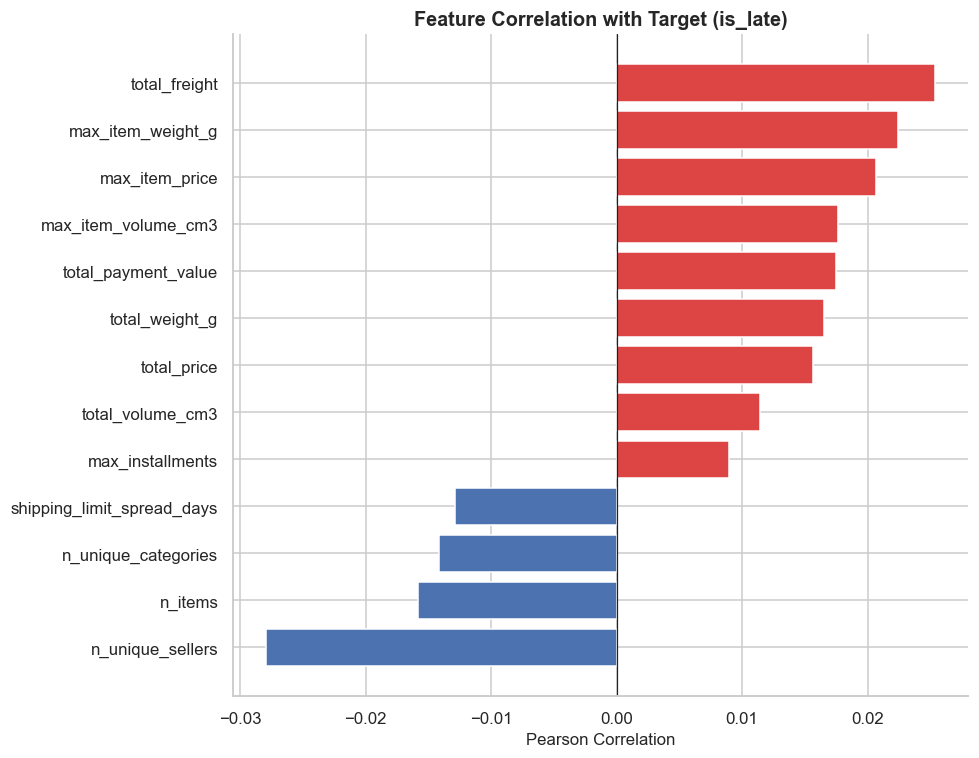

Top positive correlations with is_late :
  total_freight                  : +0.0253
  max_item_weight_g              : +0.0224
  max_item_price                 : +0.0206
  max_item_volume_cm3            : +0.0176
  total_payment_value            : +0.0175

Top negative correlations with is_late :
  n_unique_sellers               : -0.0279
  n_items                        : -0.0158
  n_unique_categories            : -0.0141


In [40]:
target_corr = corr['is_late'].drop('is_late').sort_values()

fig, ax = plt.subplots(figsize=(9, 7))
colors = [LATE_C if v > 0 else ON_TIME_C for v in target_corr.values]
ax.barh(target_corr.index, target_corr.values, color=colors, edgecolor='white')
ax.axvline(0, color='#222', lw=0.8)
ax.set_title('Feature Correlation with Target (is_late)')
ax.set_xlabel('Pearson Correlation')
sns.despine()
plt.tight_layout()
plt.show()

print('Top positive correlations with is_late :')
for feat, val in target_corr.nlargest(5).items():
    print(f'  {feat:<30s} : {val:+.4f}')
print('\nTop negative correlations with is_late :')
for feat, val in target_corr.nsmallest(3).items():
    print(f'  {feat:<30s} : {val:+.4f}')

**Insight:**

**Multicollinearity clusters to watch:**
- `total_price` ↔ `total_payment_value` — near-perfect correlation; keep one
- `total_weight_g` ↔ `total_volume_cm3` ↔ `total_freight` — freight is priced by size/weight
- `n_items` ↔ `n_unique_sellers` ↔ `n_unique_categories` — order complexity cluster

**Target correlations:**
- Individual linear correlations with `is_late` are weak (< 0.15), which is expected —
  late delivery depends on many factors interacting non-linearly.
- Freight, weight, and volume show the strongest positive signals.
- Weak individual correlations suggest tree-based models (which capture feature interactions)
  will likely outperform linear ones.

**Feature engineering direction:**
- Consider selecting representative features from correlated clusters to reduce
  multicollinearity.
- Interaction features (e.g., weight × distance) may capture non-linear effects.
- Distance-based features (not yet available — built in NB04) are expected to be among
  the strongest predictors.

---
## 8 — Key Findings & Modelling Implications

### Findings

| # | Finding | Implication |
|---|---------|-------------|
| 1 | **Class imbalance** — 8.1% late vs 91.9% on-time (11.3 : 1) | Use class weights, SMOTE, or threshold tuning. Evaluate with F1 / PR-AUC, not accuracy |
| 2 | **Physical features matter** — freight, weight, volume are higher for late orders | Known pre-shipment; should be strong predictors |
| 3 | **Geography is a strong signal** — Northern states have 2–3× the late rate of Southeast | Engineer seller → customer distance in NB04 |
| 4 | **Temporal variation** — monthly and day-of-week patterns visible | Include purchase month/quarter and day-of-week as features |
| 5 | **Weak individual correlations** — no single feature strongly predicts late delivery | Non-linear models (tree-based) likely outperform linear ones; interaction features may help |
| 6 | **Multicollinearity** — price/payment, weight/volume/freight clusters are redundant | Apply feature selection or pick one representative per cluster |
| 7 | **Leakage features identified** — `delivery_days`, `delivery_status`, `review_score` | Must be excluded from model features — post-delivery information |
| 8 | **Multi-item orders** have higher late rates | Order complexity (`n_items`, `n_sellers`) is a useful predictor |
| 9 | **Category encodes shipping difficulty** — bulky/heavy categories (furniture, appliances) have the highest late rates | Category-level features or physical proxies are strong predictors |
| 10 | **Seller identity matters** — late rates vary widely across sellers; worst sellers reach 40%+ even with 30+ orders | Seller-level features (historical late rate, state, volume) worth engineering in NB04 |

### Features to engineer in NB04

| Feature | Source | Rationale |
|---------|--------|-----------|
| Seller → customer distance | Geo coordinates | Geography is the strongest signal identified |
| Estimated delivery buffer | `estimated_date – purchase_date` | The “promise window” the seller set |
| Processing time | `carrier_date – purchase_date` | Operational efficiency signal |
| Purchase timing | Month, day of week, hour | Temporal patterns observed |
| Log-transformed price/freight/weight | Existing features | Reduce right-skew for modelling |
| Seller historical late rate | `items_enriched` + target | Seller performance varies widely (Section 6b) |
| Seller state | `items_enriched` | Seller location affects shipping distance |
| Dominant product category | `items_enriched` | Category encodes physical shipping difficulty |

### Modelling considerations

- **Baseline:** majority class = 91.9% accuracy — model must beat this meaningfully on F1
- **Start with tree-based models** (Random Forest, XGBoost) given non-linear patterns
- **Stratified train/test split** to preserve class distribution
- **Consider time-based split** (train on earlier orders, test on later) for realistic evaluation

---

**Next step:** `04_feature_engineering.ipynb`